# Fast Agent (Cloudflare Workers AI) — Build a SQL Agent fast!

Same flow as `L1_fast_agent.ipynb`, but the chat model is **Cloudflare Workers AI** via `ChatCloudflareWorkersAI`. Compared to the OpenAI path:

- **Credentials:** set `CF_AI_API_TOKEN` and `CF_ACCOUNT_ID` in `.env` with **real values**, not the `example.env` placeholders. Account ID: Cloudflare Dashboard → any Workers overview URL contains `/accounts/<id>/`, or **My Profile** → **API** → **Account ID**. `langchain-cloudflare` 0.3+ reads `CF_AI_API_TOKEN`; the code below also falls back to `CF_AI_API_KEY`.
- **Models:** Workers AI uses binding names like `@cf/meta/llama-3.3-70b-instruct-fp8-fast`; override with `CF_WORKERS_AI_MODEL` if needed.
- **Code:** use `ChatCloudflareWorkersAI` explicitly; Cloudflare is not exposed as a `provider:model` string on `init_chat_model` in current LangChain docs.

<img src="./assets/LC_L1_top.png" align="left" width="500">

## Setup

Load and/or check environment variables. **`load_dotenv()` only reads a file named `.env`** (searched below). It does **not** read `example.env` — copy `example.env` → `.env` and edit `.env`. For this notebook, set `CF_AI_API_TOKEN` (or legacy `CF_AI_API_KEY`) and `CF_ACCOUNT_ID`. Optional: `CF_WORKERS_AI_MODEL`.

In [1]:
from pathlib import Path

from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Resolve .env: Jupyter cwd is often repo root while this lesson's .env lives in python/
_dotenv_file = next(
    (p for p in (Path.cwd() / ".env", Path.cwd() / "python" / ".env") if p.is_file()),
    None,
)
if _dotenv_file:
    load_dotenv(_dotenv_file)
    print(f"Loaded .env from: {_dotenv_file.resolve()}")
else:
    load_dotenv()
    _cwd = Path.cwd().resolve()
    print(
        f"No .env at {_cwd}/.env or {_cwd}/python/.env; "
        f"fell back to python-dotenv default search (cwd={_cwd})"
    )

# Check and print results (same file we loaded, when found)
doublecheck_env(str(_dotenv_file) if _dotenv_file else ".env")
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)

Loaded .env from: C:\MarkDev\lca-langchainV1-essentials\python\.env
OPENAI_API_KEY=****here
LANGSMITH_API_KEY=****3e8d
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials
GROQ_API_KEY=****MPIf
CF_AI_API_TOKEN=****bf9b
CF_ACCOUNT_ID=****1f1e
CF_WORKERS_AI_MODEL=****a12b
Python 3.11.11 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status              | path                                                                
---------------------- | -------- | --------- | ------------------- | --------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.0.10rc1 | ⚠️ Version mismatch | C:\MarkDev\lca-langchainV1-essentials\python\.venv\Lib\site-packages
langchain              | >=1.0.0  | 1.2.6     | ✅ OK                | C:\MarkDev\lca-langchainV1-essentials\python\.venv\Lib\site-packages
langchain-core         | >=1.0.0  | 1.2.22    | ✅ OK                | C:\MarkDev\lca-langchainV1-essentials\python\.venv\

In [2]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [3]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [4]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [5]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent with **Cloudflare Workers AI** (`langchain-cloudflare`), tools, prompt, and runtime context. See [ChatCloudflareWorkersAI](https://docs.langchain.com/oss/python/integrations/chat/cloudflare_workersai) and [integrations](https://docs.langchain.com/oss/python/integrations/providers).

In [6]:
import os

from langchain.agents import create_agent
from langchain_cloudflare.chat_models import ChatCloudflareWorkersAI

# CF_AI_API_TOKEN is what langchain-cloudflare reads; CF_AI_API_KEY kept for older .env files.
_cf_ai_token = (os.getenv("CF_AI_API_TOKEN") or os.getenv("CF_AI_API_KEY") or "").strip()
_cf_account = (os.getenv("CF_ACCOUNT_ID") or "").strip()

# Catch unreplaced example.env values early (otherwise Cloudflare returns 404 on .../accounts/your_cloudflare_account_id_here/...)
if _cf_account in frozenset(("", "your_cloudflare_account_id_here")):
    raise ValueError(
        "CF_ACCOUNT_ID is missing or still the example.env placeholder. "
        "Set it in .env to your real Cloudflare account ID (Dashboard URL or Account API section)."
    )
if _cf_ai_token in frozenset(
    ("", "your_cloudflare_api_token_here", "your_cloudflare_workers_ai_api_key_here")
):
    raise ValueError(
        "CF_AI_API_TOKEN (or legacy CF_AI_API_KEY) is missing or still an example.env placeholder. "
        "Create an API token with Workers AI permissions and set it in .env."
    )

model = ChatCloudflareWorkersAI(
    model=os.getenv("CF_WORKERS_AI_MODEL", "@cf/moonshotai/kimi-k2.5"),
    api_token=_cf_ai_token,
    account_id=_cf_account,
    temperature=0,
    max_tokens=1024,
)

agent = create_agent(
    model=model,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

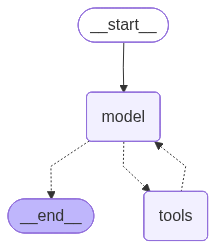

In [7]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

**Streaming note:** The Cloudflare Workers AI LangChain integration may not support the same **token-level** streaming as some other providers; `agent.stream` with `stream_mode="values"` still advances the graph step-by-step so you see each message.

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [8]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': "We need to find which table has the largest number of entries (rows). We need to list tables and count rows. We can query sqlite_master to get table names, then for each table count rows. Since we can only execute one SELECT query per tool call? Actually we can call execute_sql multiple times, but each call must be a SELECT query. We can do multiple calls. But we need to find the table with max rows. We could query each table's row count using a UNION ALL approach? But we don't know table names ahead. We can first get table names, then loop? But we cannot loop in SQL easily without knowing names. However we can use PRAGMA table_info? Not for row count. We could use sqlite_master and then use a query that selects count(*) from each table using d

In [11]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': ' The user wants to know which genre has the longest average track length. I need to look at the database schema to understand what tables are available and how they relate to each other.\n\nLet me first explore the database to see what tables exist and their structure. '}]
Tool Calls:
  execute_sql (functions.execute_sql:0)
 Call ID: functions.execute_sql:0
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message =

In [11]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': " The user wants to see all tables in the database. I'll query the sqlite_master table to get this information. "}]
Tool Calls:
  execute_sql (functions.execute_sql:0)
 Call ID: functions.execute_sql:0
  Args:
    query: SELECT name, type FROM sqlite_master WHERE type='table' ORDER BY name
================================= Tool Message =================================
Name: execute_sql

[('Album', 'table'), ('Artist', 'table'), ('Customer', 'table'), ('Employee', 'table'), ('Genre', 'table'), ('Invoice', 'table'), ('InvoiceLine', 'table'), ('MediaType', 'table'), ('Playlist', 'table'), ('PlaylistTrack', 'table'), ('Track', 'table')]
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': ' The query re

**Create your own query here!**  Add some questions of your own.

In [9]:
question = "Provide a list of top 5 artists with the most number of tracks"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Provide a list of top 5 artists with the most number of tracks
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'We need to list top 5 artists with most number of tracks. We need to know the schema. Likely there is a table "artists" and "tracks" with foreign key artist_id. Let\'s first inspect schema. Use execute_sql to get tables.\n'}]
Tool Calls:
  execute_sql (chatcmpl-tool-9f77231b2f9b5c75)
 Call ID: chatcmpl-tool-9f77231b2f9b5c75
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message =================================

### Let's try this Studio